In [1]:
from brian2 import *
import numpy as np
from numpy import sqrt
import matplotlib.pyplot as plt     # DELETE
#matplotlib.use('agg')  # DELETE

import plot_utils as pu

In [2]:
from brian2 import start_scope
import numpy as np
from brian2 import seed

np.random.seed(500)
seed(500)  # <- This makes the entire simulation reproducible
start_scope()

# Define MEA representation with 32x32 electrodes
size = 3.75 * mmeter  # Physical size of the lattice/grid
electrode_spacing = 100 * umeter
grid_size = 32  # 32x32 grid
electrode_positions = [(i * size / grid_size - size / 2,
                        j * size / grid_size - size / 2)
                       for i in range(grid_size) for j in range(grid_size)]

# General parameters
duration = 15*second          # Total simulation time
N_e = 1000                   # Number of excitatory neurons
N_i = 250                    # Number of inhibitory neurons
N_a = 5500                   # Number of astrocytes

# Neuron parameters
E_l = -60*mV                 # Leak reversal potential
g_l = 9.99*nS                # Leak conductance
E_e = 0*mV                   # Excitatory synaptic reversal potential
E_i = -80*mV                 # Inhibitory synaptic reversal potential
C_m = 198*pF                 # Membrane capacitance
tau_e = 5*ms                 # Excitatory synaptic time constant
tau_i = 10*ms                # Inhibitory synaptic time constant
tau_r = 5*ms                 # Refractory period
I_ex = 100*pA                 # Low baseline External current
V_th = -50*mV                # Firing threshold
V_r = E_l                    # Reset potential

# Synapse parameters
rho_c = 0.005                # Synaptic vesicle-to-extracellular space volume ratio
Y_T = 500.*mmolar            # Total vesicular neurotransmitter concentration
Omega_c = 40/second          # Neurotransmitter clearance rate
U_0__star = 0.6              # Resting synaptic release probability
Omega_f = 3.33/second        # Synaptic facilitation rate
Omega_d = 2.0/second         # Synaptic depression rate
w_e = 0.05*nS                # Excitatory synaptic conductance
w_i = 1.0*nS                 # Inhibitory synaptic conductance

# Presynaptic receptors
O_G = 1.5/umolar/second      # Agonist binding (activating) rate
Omega_G = 0.5/(60*second)    # Agonist release (deactivating) rate

# Astrocyte parameters
# Calcium fluxes
O_P = 0.9*umolar/second      # Maximal Ca^2+ uptake rate by SERCAs
K_P = 0.05*umolar            # Ca2+ affinity of SERCAs
C_T = 2*umolar               # Total cell free Ca^2+ content
rho_A = 0.18                 # ER-to-cytoplasm volume ratio
Omega_C = 6/second           # Maximal rate of Ca^2+ release by IP_3Rs
Omega_L = 0.1/second         # Maximal rate of Ca^2+ leak from the ER

# IP_3R kinectics
d_1 = 0.13*umolar            # IP_3 binding affinity
d_2 = 1.05*umolar            # Ca^2+ inactivation dissociation constant
O_2 = 0.2/umolar/second      # IP_3R binding rate for Ca^2+ inhibition
d_3 = 0.9434*umolar          # IP_3 dissociation constant
d_5 = 0.08*umolar            # Ca^2+ activation dissociation constant

# IP_3 production
# Agonist-dependent IP_3 production
O_beta = 0.5*umolar/second   # Maximal rate of IP_3 production by PLCbeta
O_N = 0.3/umolar/second      # Agonist binding rate
Omega_N = 0.5/second         # Maximal inactivation rate
K_KC = 0.5*umolar            # Ca^2+ affinity of PKC
zeta = 10                    # Maximal reduction of receptor affinity by PKC

# Endogenous IP3 production
O_delta = 1.2*umolar/second  # Maximal rate of IP_3 production by PLCdelta
kappa_delta = 1.5*umolar     # Inhibition constant of PLC_delta by IP_3
K_delta = 0.05*umolar         # Ca^2+ affinity of PLCdelta

# IP_3 degradation
Omega_5P = 0.05/second       # Maximal rate of IP_3 degradation by IP-5P
K_D = 0.7*umolar             # Ca^2+ affinity of IP3-3K
K_3K = 1.0*umolar            # IP_3 affinity of IP_3-3K
O_3K = 4.5*umolar/second     # Maximal rate of IP_3 degradation by IP_3-3K

# IP_3 diffusion
F = 0.1*umolar/second        # GJC IP_3 permeability
I_Theta = 0.1*umolar         # Threshold gradient for IP_3 diffusion
omega_I = 0.01*umolar        # Scaling factor of diffusion

# Gliotransmitter release and time course
C_Theta = 0.5*umolar         # Ca^2+ threshold for exocytosis
Omega_A = 0.6/second         # Gliotransmitter recycling rate
U_A = 0.9                    # Gliotransmitter release probability
G_T = 600*mmolar             # Total vesicular gliotransmitter concentration
rho_e = 3.0e-3               # Astrocytic vesicle-to-extracellular volume ratio
Omega_e = 30/second          # Gliotransmitter clearance rate
alpha = 0.2                  # Gliotransmission nature

# Neurons Eqn
dt = 0.1*ms
defaultclock.dt = dt
sigma_noise = 1.1*mV/sqrt(ms) #Higher amplitude for stronger random spiking  # noise explicitly in volt/sqrt(second)

neuron_equations = '''
dv/dt = (g_l*(E_l - v) + g_e*(E_e - v) + g_i*(E_i - v) + I_astro)/C_m
        + sigma_noise*xi : volt (unless refractory)
dg_e/dt = -g_e/tau_e : siemens
dg_i/dt = -g_i/tau_i : siemens
I_astro : amp
x : meter (constant)
y : meter (constant)
'''

neurons = NeuronGroup(N_e + N_i, model=neuron_equations,
                      threshold='v>V_th', reset='v=V_r',
                      refractory='tau_r', method='euler')

# Random initial membrane potential values and conductances
exc_neurons = neurons[:N_e]
inh_neurons = neurons[N_e:]

# Arrange excitatory neurons in a grid
N_rows = int(sqrt(N_e))
N_cols = N_e/N_rows
grid_dist = (size / N_cols)

# Use a normal distribution centered at (0,0) with some spread
spread = size / 4  # Adjust spread for more clustering
exc_neurons.x = 'clip(randn() * spread, -size/2, size/2)'
exc_neurons.y = 'clip(randn() * spread, -size/2, size/2)'
inh_neurons.x = 'clip(randn() * spread, -size/2, size/2)'
inh_neurons.y = 'clip(randn() * spread, -size/2, size/2)'

# Random initial membrane potential values and conductances
neurons.v = 'E_l + rand()*(V_th-E_l)'
neurons.g_e = 'rand()*w_e'
neurons.g_i = 'rand()*w_i'

# Synapses Eqn
synapses_equations = '''
# Neurotransmitter
dY_S/dt = -Omega_c * Y_S : mmolar (clock-driven)
# Fraction of activated presynaptic receptors
dGamma_S/dt = O_G * G_A * (1 - Gamma_S) - Omega_G * Gamma_S : 1 (clock-driven)
# Usage of releasable neurotransmitter per single action potential:
du_S/dt = -Omega_f * u_S                                    : 1 (event-driven)
# Fraction of synaptic neurotransmitter resources available for release:
dx_S/dt = Omega_d *(1 - x_S)                                : 1 (event-driven)
U_0                                                         : 1
# released synaptic neurotransmitter resources:
r_S                                                         : 1
# gliotransmitter concentration in the extracellular space:
G_A                                                         : mmolar
# which astrocyte covers this synapse ?
astrocyte_index : integer (constant)
'''

synapses_action = '''
U_0 = (1 - Gamma_S) * U_0__star + alpha * Gamma_S  # Explicit astrocyte-dependent modulation
u_S += U_0 * (1 - u_S)
r_S = u_S * x_S
x_S -= r_S
Y_S += rho_c * Y_T * r_S  # Neurotransmitter released into extracellular space
g_e_post += w_e * r_S * (1 + Gamma_S)  # Astrocytic gliotransmission enhances synaptic efficacy
'''

# Neuron Connections
exc_syn = Synapses(exc_neurons, neurons, model=synapses_equations,
               on_pre=synapses_action+'g_e_post += w_e*r_S',
               method='linear')

exc_syn.connect(True, p=0.05)
exc_syn.x_S = 1.0
inh_syn = Synapses(inh_neurons, neurons, model=synapses_equations,
               on_pre=synapses_action+'g_i_post += w_i*r_S',
               method='linear')
inh_syn.connect(True, p=0.15)
inh_syn.x_S = 1.0

# Connect excitatory synapses to an astrocyte depending on the position of the post-synaptic neuron
N_rows_a = int(sqrt(N_a))
N_cols_a = N_a/N_rows_a
grid_dist = size / (N_rows_a)
exc_syn.astrocyte_index = ('int(x_post/grid_dist) + '
                       'N_cols_a*int(y_post/grid_dist)')

# Astrocytes
# The astrocyte emits gliotransmitter when its Ca^2+ concentration crosses a threshold
astro_equations = '''
# Fraction of activated astrocyte receptors:
dGamma_A/dt = O_N * Y_S * (1 - clip(Gamma_A,0,1)) -
          Omega_N*(1 + zeta * C/(C + K_KC)) * clip(Gamma_A,0,1) : 1
# Intracellular IP_3
dI/dt = J_beta + J_delta - J_3K - J_5P + J_coupling              : mmolar
J_beta = O_beta * Gamma_A                                        : mmolar/second
J_delta = O_delta/(1 + I/kappa_delta) * C**2/(C**2 + K_delta**2) : mmolar/second
J_3K = O_3K * C**4/(C**4 + K_D**4) * I/(I + K_3K)                : mmolar/second
J_5P = Omega_5P*I                                                : mmolar/second
# Diffusion between astrocytes:
J_coupling                                                       : mmolar/second

# Ca^2+-induced Ca^2+ release:
dC/dt = J_r + J_l - J_p                                   : mmolar
dh/dt = (h_inf - h)/tau_h                                 : 1
J_r = (Omega_C * m_inf**3 * h**3) * (C_T - (1 + rho_A)*C) : mmolar/second
J_l = Omega_L * (C_T - (1 + rho_A)*C)                     : mmolar/second
J_p = O_P * C**2/(C**2 + K_P**2)                          : mmolar/second
m_inf = I/(I + d_1) * C/(C + d_5)                         : 1
h_inf = Q_2/(Q_2 + C)                                     : 1
tau_h = 1/(O_2 * (Q_2 + C))                               : second
Q_2 = d_2 * (I + d_1)/(I + d_3)                           : mmolar

# Fraction of gliotransmitter resources available for release:
dx_A/dt = Omega_A * (1 - x_A) : 1
# gliotransmitter concentration in the extracellular space:
dG_A/dt = -Omega_e*G_A        : mmolar
# Neurotransmitter concentration in the extracellular space:
Y_S                           : mmolar
C_Theta : mmolar (constant)
O_delta : mmolar/second (constant)
# The astrocyte position in space
x : meter (constant)
y : meter (constant)
'''
glio_release = '''
G_A += rho_e * G_T * U_A * x_A
x_A -= U_A *  x_A
'''

# Astrocyte Eqn
astrocytes = NeuronGroup(N_a, astro_equations,
                     threshold='C>C_Theta',
                     refractory='C>C_Theta',
                     reset=glio_release,
                     method='rk4',
                     dt=1e-2*second)

astrocytes.C_Theta = '0.3*umolar + 0.2*umolar*rand()'
astrocytes.O_delta = '1.0*umolar/second + 0.5*umolar/second*rand()'

spread = size / 4  # Controls clustering size
astrocytes.x = 'clip(randn() * spread, -size/2, size/2)'
astrocytes.y = 'clip(randn() * spread, -size/2, size/2)'

# Add random initialization
astrocytes.C = 0.01*umolar
astrocytes.h = 0.9
astrocytes.I = 0.01*umolar
astrocytes.x_A = 1.0

# Astrocyte connections to Neuron network
ecs_astro_to_syn = Synapses(astrocytes, exc_syn,
                        'G_A_post = G_A_pre : mmolar (summed)')
ecs_astro_to_syn.connect('i == astrocyte_index_post')# Increase astro-to-synapse connection probability
ecs_syn_to_astro = Synapses(exc_syn, astrocytes,
                        'Y_S_post = Y_S_pre/N_incoming : mmolar (summed)')
ecs_syn_to_astro.connect('astrocyte_index_pre == j')

# Diffusion between astrocytes
astro_to_astro_equations = '''
delta_I = I_post - I_pre : mmolar
C_avg = (C_pre + C_post) / 2 : mmolar
scaling_factor = 1 / (1 + exp(-10 * ((C_avg / umolar) - (C_Theta / umolar)))) : 1  # Sigmoid dependence on calcium
J_coupling_post = -(1 + tanh((abs(delta_I) - I_Theta) / omega_I)) * sign(delta_I) * F * scaling_factor / 2 : mmolar/second (summed)
'''

astro_to_neuron = Synapses(astrocytes, neurons, '''
                           I_astro_post = g_astro * G_A_pre : amp (summed)''')
astro_to_neuron.connect('sqrt((x_pre - x_post)**2 + (y_pre - y_post)**2) < 150*um')
g_astro = 250*pA/mmolar #stronger astrocytic influence

astro_to_astro = Synapses(astrocytes, astrocytes,
                      model=astro_to_astro_equations)
# Connect to all astrocytes less than 50um away mimicking GJCs
astro_to_astro.connect('i != j and '
                   'sqrt((x_pre-x_post)**2 +'
                   '     (y_pre-y_post)**2) < 50*um')

# Monitors
exc_mon = SpikeMonitor(exc_neurons)
inh_mon = SpikeMonitor(inh_neurons)
ast_mon = SpikeMonitor(astrocytes)

# We record some additional data from a single excitatory neuron
ni = 100
# Record conductances and membrane potential of neuron ni
state_mon = StateMonitor(exc_neurons, ['v', 'g_e', 'g_i'], record=ni)
synapse_mon = StateMonitor(exc_syn, ['u_S', 'x_S', 'r_S'],
                       record=exc_syn[ni, :], when='after_synapses')

astro_mon_G_A = StateMonitor(astrocytes, 'G_A', record=True)
astro_mon_coupling = StateMonitor(astrocytes, 'J_coupling', record=True) #Monitor astro-astro calcium diffusion
astro_mon_C = StateMonitor(astrocytes, 'C', record=True) #Monitor astrocyte intracellular calcium

# Simulation run
################################################################################
run(duration, report='text')


# Analyze MEA activity, Convert neuron_positions to have units of meters
mea_activity = np.zeros((grid_size, grid_size))  # 22x22 MEA grid resolution
neuron_positions = np.array([neurons.x[:], neurons.y[:]]) * meter  # Explicitly add units, necessary for consistent units
astro_positions = np.array([astrocytes.x[:], astrocytes.y[:]]) * meter

for i, pos in enumerate(electrode_positions):
    x, y = pos  # Electrode position

    # Neuron contribution
    distance = np.sqrt((neuron_positions[0, :] - x)**2 +
                       (neuron_positions[1, :] - y)**2)
    weights = 1 / (distance + 1e-6 * meter)
    spike_count = np.sum(weights[:N_e] * exc_mon.count[:]) + \
                  np.sum(weights[N_e:] * inh_mon.count[:])

    # Astrocyte contribution
    distance_astro = np.sqrt((astro_positions[0, :] - x)**2 +
                             (astro_positions[1, :] - y)**2)
    weights_astro = 1 / (distance_astro + 1e-6 * meter)
    gliotransmitter_influence = np.sum(weights_astro * astro_mon_G_A.G_A[:, -1] * meter)

    # Normalize astrocyte influence to make it dimensionless
    normalized_gliotransmitter_influence = gliotransmitter_influence / umolar

    # Combine neuron and astrocyte contributions
    scaling_factor = 10.0  # Increase if needed
    spike_count *= (1 + scaling_factor * normalized_gliotransmitter_influence) #Scale neuron activity by astrocytic influence

    mea_activity[i // grid_size, i % grid_size] = spike_count

# Normalize MEA activity
mea_activity /= np.percentile(mea_activity, 95)  # Normalize to 95th percentile
mea_activity = np.clip(mea_activity, 0, 1)  # Cap values between 0 and 1

#Print Results
print(f"Number of spikes from excitatory neurons: {exc_mon.num_spikes}")
print(f"Number of spikes from inhibitory neurons: {inh_mon.num_spikes}")
print(f"Total excitatory synaptic connections: {len(exc_syn)}")
print(f"Total inhibitory synaptic connections: {len(inh_syn)}")
print(f"Connected astrocytes to synapses: {len(ecs_astro_to_syn)}")
print(f"Number of astro-to-astro connections: {len(astro_to_astro)}")

WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    'C_Theta' is an internal variable of group 'neurongroup_1', but also exists in the run namespace with the value 0.5 * umolar. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'O_delta' is an internal variable of group 'neurongroup_1', but also exists in the run namespace with the value 0.0012 * mmolar / second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'C_Theta' is an internal variable of group 'synapses_5', but also exists in the run namespace with the value 0.5 * umolar. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'dt' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value 100. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.r

Starting simulation at t=0. s for a duration of 15. s
2.7782 s (18%) simulated in 10s, estimated 44s remaining.
5.5467 s (36%) simulated in 20s, estimated 34s remaining.
8.3482 s (55%) simulated in 30s, estimated 24s remaining.
11.1273 s (74%) simulated in 40s, estimated 14s remaining.
13.9288 s (92%) simulated in 50s, estimated 4s remaining.
15. s (100%) simulated in 53s
Number of spikes from excitatory neurons: 137457
Number of spikes from inhibitory neurons: 34426
Total excitatory synaptic connections: 62452
Total inhibitory synaptic connections: 46927
Connected astrocytes to synapses: 30843
Number of astro-to-astro connections: 23744


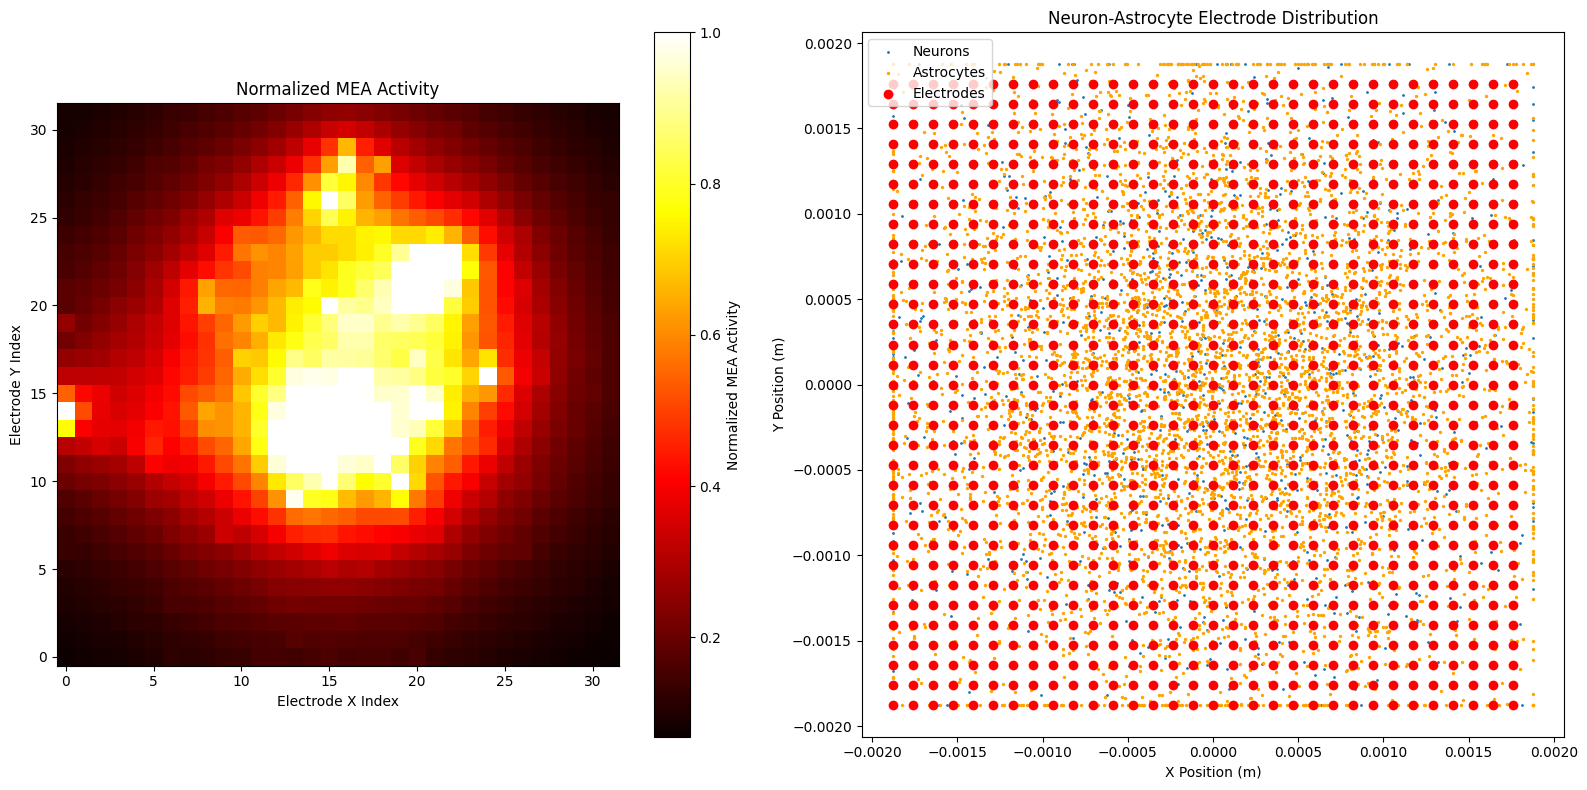

In [3]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 8))  # 1 row, 2 columns

# Subplot 1: MEA activity heatmap
im = axs[0].imshow(mea_activity, cmap='hot', interpolation='nearest', origin='lower')
fig.colorbar(im, ax=axs[0], label="Normalized MEA Activity")
axs[0].set_title("Normalized MEA Activity")
axs[0].set_xlabel("Electrode X Index")
axs[0].set_ylabel("Electrode Y Index")

# Subplot 2: Neuron-Astrocyte-Electrode distribution
axs[1].scatter(exc_neurons.x[:] / meter, exc_neurons.y[:] / meter, s=1, label='Neurons')
axs[1].scatter(astrocytes.x[:] / meter, astrocytes.y[:] / meter, color='orange', s=2, label='Astrocytes')
axs[1].scatter([pos[0] for pos in electrode_positions],
               [pos[1] for pos in electrode_positions], c='red', label='Electrodes')
axs[1].legend()
axs[1].set_xlabel("X Position (m)")
axs[1].set_ylabel("Y Position (m)")
axs[1].set_title("Neuron-Astrocyte Electrode Distribution")

# Show combined figure
plt.tight_layout()
plt.show()

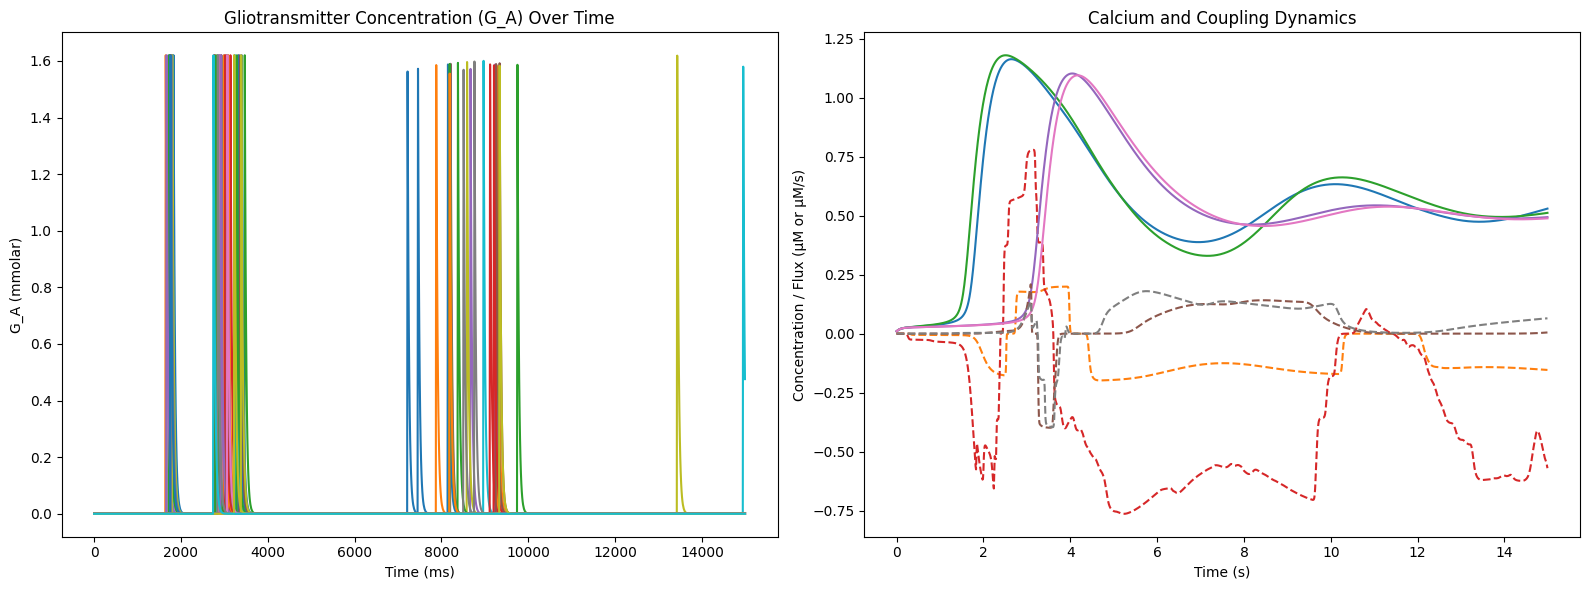

Astrocyte 0 coupling: [ 0.00000000e+00  0.00000000e+00 -4.50487627e-12 ... -7.67232312e-02
 -7.67847495e-02 -7.68462303e-02] uM/s
Astrocyte 0 calcium levels: [ 10.          11.58539877  13.05458848 ... 528.75888464 529.28451806
 529.81015893] nM
Astrocyte 1 coupling: [ 0.00000000e+00  0.00000000e+00 -1.72618994e-11 ... -2.75222132e-01
 -2.79955765e-01 -2.84970684e-01] uM/s
Astrocyte 1 calcium levels: [ 10.          11.58540012  13.05460365 ... 511.26873451 511.54885481
 511.83153752] nM
Astrocyte 29 coupling: [0.00000000e+00 0.00000000e+00 7.29749311e-12 ... 2.41033556e-03
 2.48733501e-03 2.56597295e-03] uM/s
Astrocyte 29 calcium levels: [ 10.          11.58539928  13.05458693 ... 493.42884568 493.55628079
 493.6848656 ] nM
Astrocyte 30 coupling: [0.00000000e+00 0.00000000e+00 2.58001674e-12 ... 3.23739749e-02
 3.24535952e-02 3.25330552e-02] uM/s
Astrocyte 30 calcium levels: [ 10.          11.58539905  13.05458561 ... 488.36521376 488.48826884
 488.6129131 ] nM


In [4]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots side-by-side
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Gliotransmitter Concentration (G_A) over time
axs[0].set_title("Gliotransmitter Concentration (G_A) Over Time")
for i in range(50):
    axs[0].plot(astro_mon_G_A.t / ms, astro_mon_G_A.G_A[i] / mmolar, label=f'Astrocyte {i}')
axs[0].set_xlabel("Time (ms)")
axs[0].set_ylabel("G_A (mmolar)")
# axs[0].legend()  # Optional: enable if needed

# Subplot 2: Calcium and Coupling Dynamics
time = astro_mon_C.t
astro_indices_to_plot = [0, 1, 29, 30]

for astro_idx in astro_indices_to_plot:
    calcium_signal = astro_mon_C.C[astro_idx]
    coupling_signal = 2 * astro_mon_coupling.J_coupling[astro_idx]

    axs[1].plot(time / second, calcium_signal / umolar, label=f'Ca²⁺ - Astro {astro_idx}')
    axs[1].plot(time / second, coupling_signal / (umolar / second),
                linestyle='--', label=f'Coupling - Astro {astro_idx}')

axs[1].set_title("Calcium and Coupling Dynamics")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Concentration / Flux (μM or μM/s)")
# axs[1].legend()  # Optional: enable if needed

# Adjust layout and show
plt.tight_layout()
plt.show()

# Print astrocyte signal data for verification (can remain outside the plot block)
for astro_idx in astro_indices_to_plot:
    print(f"Astrocyte {astro_idx} coupling: {astro_mon_coupling.J_coupling[astro_idx]}")
    print(f"Astrocyte {astro_idx} calcium levels: {astro_mon_C.C[astro_idx]}")

Raster includes: 1000 excitatory, 250 inhibitory, 5000 astrocytes


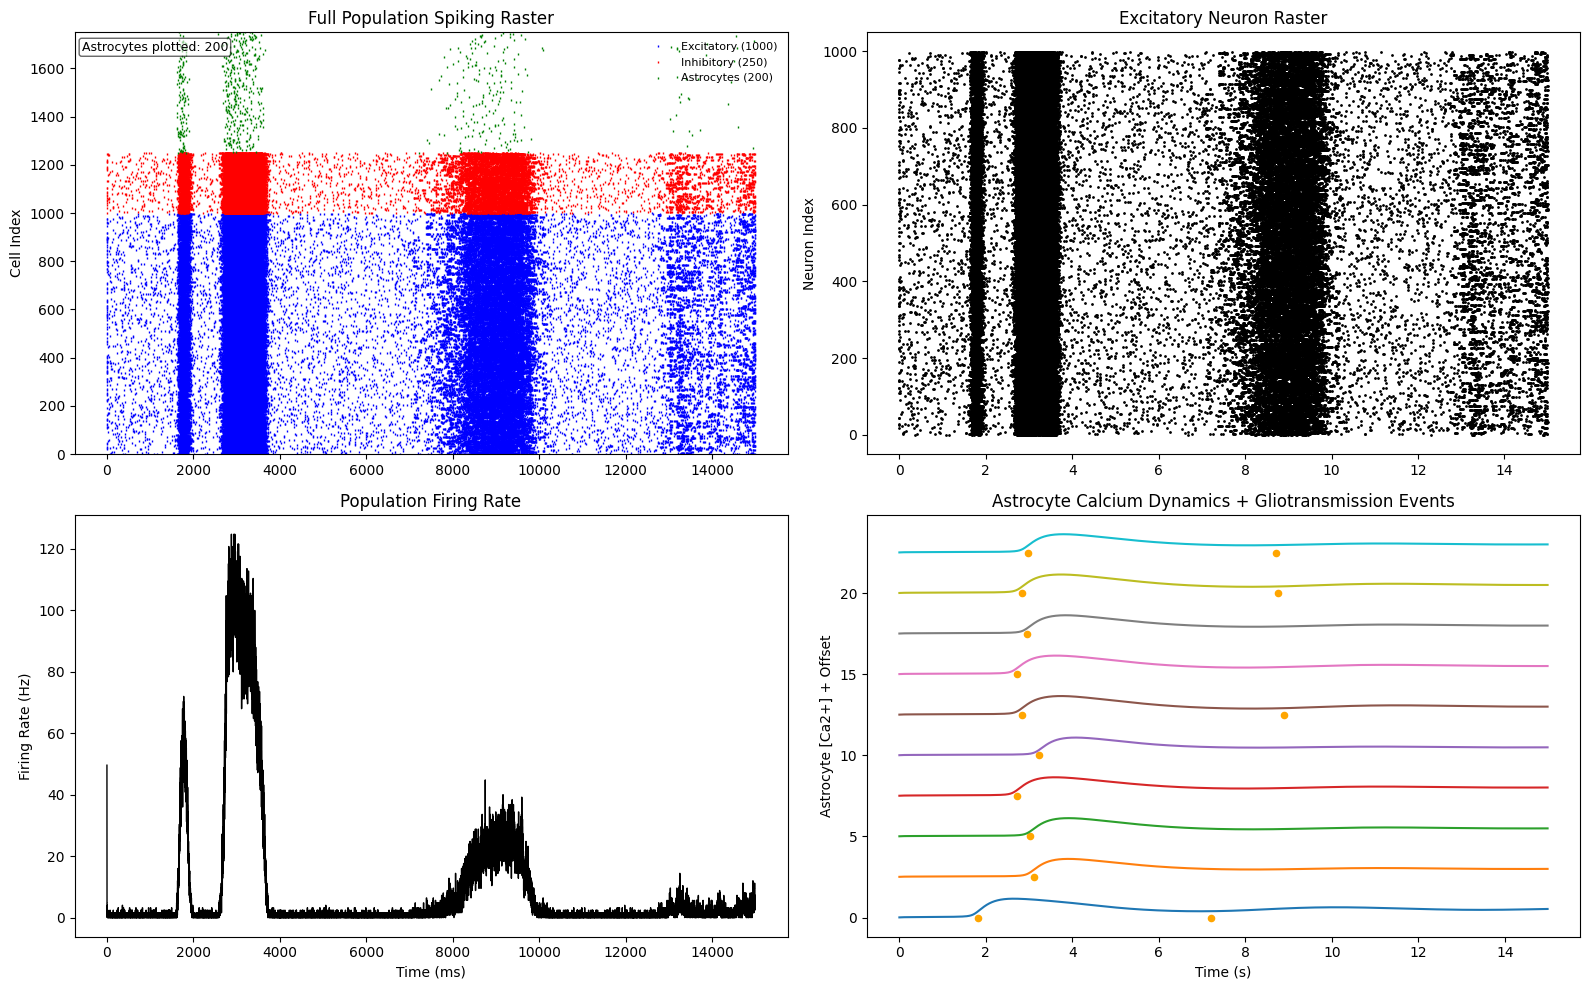

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Print Summary ---
print(f"Raster includes: {N_e} excitatory, {N_i} inhibitory, {5000} astrocytes")

# --- Offsets ---
inh_offset = N_e
ast_offset = N_e + N_i

# --- Firing Rate ---
bin_size = 1 * ms
spk_count, bin_edges = np.histogram(np.r_[exc_mon.t/ms, inh_mon.t/ms],
                                    bins=int(duration/ms))
rate = spk_count / ((N_e + N_i) * bin_size / second)  # Hz
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# --- Astrocyte Ca2+ Processing ---
exc_spike_times = np.array(exc_mon.t / second)
exc_spike_indices = np.array(exc_mon.i)
astro_calcium = np.array(astro_mon_C.C / umolar)
astro_time = np.array(astro_mon_C.t / second)
astro_thresholds_vals = astrocytes.C_Theta[:] / umolar

n_traces = 10
astro_indices = np.linspace(0, astro_calcium.shape[0] - 1, n_traces, dtype=int)
astro_traces = astro_calcium[astro_indices, :]
astro_event_times = []
for idx in astro_indices:
    trace = astro_calcium[idx]
    threshold = astro_thresholds_vals[idx]
    crossings = np.where(np.diff((trace > threshold).astype(int)) == 1)[0]
    times = astro_time[crossings]
    astro_event_times.append(times)

# --- Create Combined Figure ---
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- Plot 1: Full Raster (Exc, Inh, Astro) ---
axs[0, 0].plot(exc_mon.t/ms, exc_mon.i, '|', color='blue', markersize=1, label=f'Excitatory ({N_e})')
axs[0, 0].plot(inh_mon.t/ms, inh_mon.i + inh_offset, '|', color='red', markersize=1, label=f'Inhibitory ({N_i})')
axs[0, 0].plot(ast_mon.t/ms, ast_mon.i + ast_offset, '|', color='green', markersize=1, label='Astrocytes (200)')
axs[0, 0].set_ylabel("Cell Index")
axs[0, 0].set_ylim(0, 1750)
axs[0, 0].set_title("Full Population Spiking Raster")
axs[0, 0].legend(fontsize=8, loc="upper right", handlelength=2.5, frameon=False)
axs[0, 0].text(0.01, 0.98, "Astrocytes plotted: 200", transform=axs[0, 0].transAxes,
               fontsize=9, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.6))

# --- Plot 2: Firing Rate ---
axs[1, 0].step(bin_centers, rate, color='black', linewidth=1)
axs[1, 0].set_xlabel("Time (ms)")
axs[1, 0].set_ylabel("Firing Rate (Hz)")
axs[1, 0].set_title("Population Firing Rate")

# --- Plot 3: Excitatory Raster Only ---
axs[0, 1].scatter(exc_spike_times, exc_spike_indices, s=1, color='black')
axs[0, 1].set_ylabel("Neuron Index")
axs[0, 1].set_title("Excitatory Neuron Raster")

# --- Plot 4: Astrocyte Ca2+ Dynamics + Events ---
for i, (trace, times) in enumerate(zip(astro_traces, astro_event_times)):
    offset = i * 2.5
    axs[1, 1].plot(astro_time, trace + offset, label=f'Astro {astro_indices[i]}')
    axs[1, 1].scatter(times, np.ones_like(times) * offset, color='orange', s=20)
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].set_ylabel("Astrocyte [Ca2+] + Offset")
axs[1, 1].set_title("Astrocyte Calcium Dynamics + Gliotransmission Events")

plt.tight_layout()
plt.show()

WARNING    /var/folders/d9/jjlvpg6d3js2p7d7zyynnbdh0000gn/T/ipykernel_37821/3056662713.py:5: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  spk_index = np.in1d(synapse_mon.t, exc_mon.t[exc_mon.i == ni])
 [py.warnings]


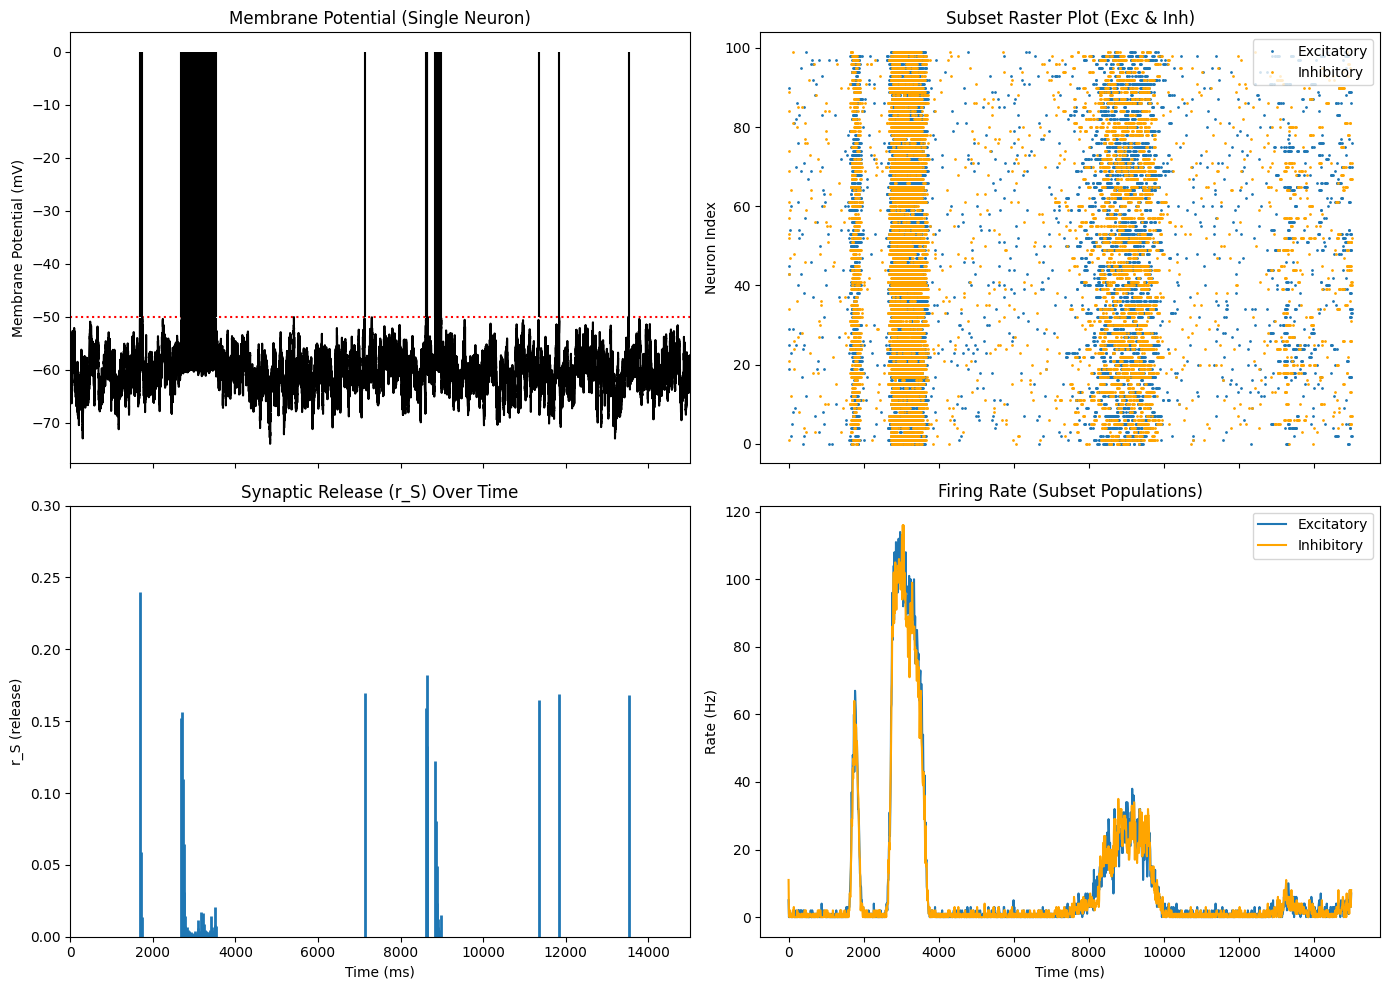

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute synaptic release for selected neuron ---
spk_index = np.in1d(synapse_mon.t, exc_mon.t[exc_mon.i == ni])
x_S_spike = synapse_mon.x_S[0][spk_index]
u_S_spike = synapse_mon.u_S[0][spk_index]
r_S_spike = x_S_spike * u_S_spike

# --- Compute firing rates for neuron subsets ---
def calculate_firing_rate_subset(spike_monitor, neuron_ids, duration, bin_size=10*ms):
    spike_times = np.array(spike_monitor.t / ms)
    spike_indices = np.array(spike_monitor.i)
    total_neurons = len(neuron_ids)
    subset_mask = np.isin(spike_indices, neuron_ids)
    subset_spike_times = spike_times[subset_mask]
    time_bins = np.arange(0, duration/ms, bin_size/ms)
    spike_hist, _ = np.histogram(subset_spike_times, bins=time_bins)
    firing_rate = spike_hist / (bin_size / second * total_neurons)
    return time_bins[:-1], firing_rate

subset_neurons_exc = range(0, 100)
subset_neurons_inh = range(0, 100)

time_bins_exc, firing_rate_exc = calculate_firing_rate_subset(exc_mon, subset_neurons_exc, duration)
time_bins_inh, firing_rate_inh = calculate_firing_rate_subset(inh_mon, subset_neurons_inh, duration)

# --- Masks for raster plots ---
exc_subset_mask = np.isin(exc_mon.i, subset_neurons_exc)
inh_subset_mask = np.isin(inh_mon.i, subset_neurons_inh)

# --- Create Column-Based Combined Figure ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex='col')
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# LEFT COLUMN — Membrane & r_S

# --- Top Left: Membrane Potential with Spikes ---
axs[0, 0].axhline(V_th/mV, color='red', linestyle=':', label="Threshold (V_th)")
axs[0, 0].plot(state_mon.t/ms, state_mon.v[0]/mV, color='black')
axs[0, 0].vlines(exc_mon.t[exc_mon.i == ni]/ms, V_th/mV, 0, color='black')
axs[0, 0].set_title("Membrane Potential (Single Neuron)")
axs[0, 0].set_ylabel("Membrane Potential (mV)")

# --- Bottom Left: Synaptic Release (r_S) ---
axs[1, 0].vlines(synapse_mon.t[spk_index]/ms, 0, r_S_spike, color='C0', linewidth=2)
axs[1, 0].set_ylim(0, 0.3)
axs[1, 0].set_xlim(0, 15000)
axs[1, 0].set_title("Synaptic Release (r_S) Over Time")
axs[1, 0].set_xlabel("Time (ms)")
axs[1, 0].set_ylabel("r_S (release)")

# RIGHT COLUMN — Raster & Firing Rate

# --- Top Right: Subset Raster Plot ---
axs[0, 1].plot(exc_mon.t[exc_subset_mask]/ms, exc_mon.i[exc_subset_mask], '.', markersize=2, label='Excitatory')
axs[0, 1].plot(inh_mon.t[inh_subset_mask]/ms, inh_mon.i[inh_subset_mask], '.', markersize=2, color='orange', label='Inhibitory')
axs[0, 1].set_title("Subset Raster Plot (Exc & Inh)")
axs[0, 1].set_ylabel("Neuron Index")
axs[0, 1].legend()

# --- Bottom Right: Firing Rate Plot ---
axs[1, 1].plot(time_bins_exc, firing_rate_exc, label='Excitatory')
axs[1, 1].plot(time_bins_inh, firing_rate_inh, color='orange', label='Inhibitory')
axs[1, 1].set_title("Firing Rate (Subset Populations)")
axs[1, 1].set_xlabel("Time (ms)")
axs[1, 1].set_ylabel("Rate (Hz)")
axs[1, 1].legend()

# --- Show Layout ---
plt.tight_layout()
plt.show()

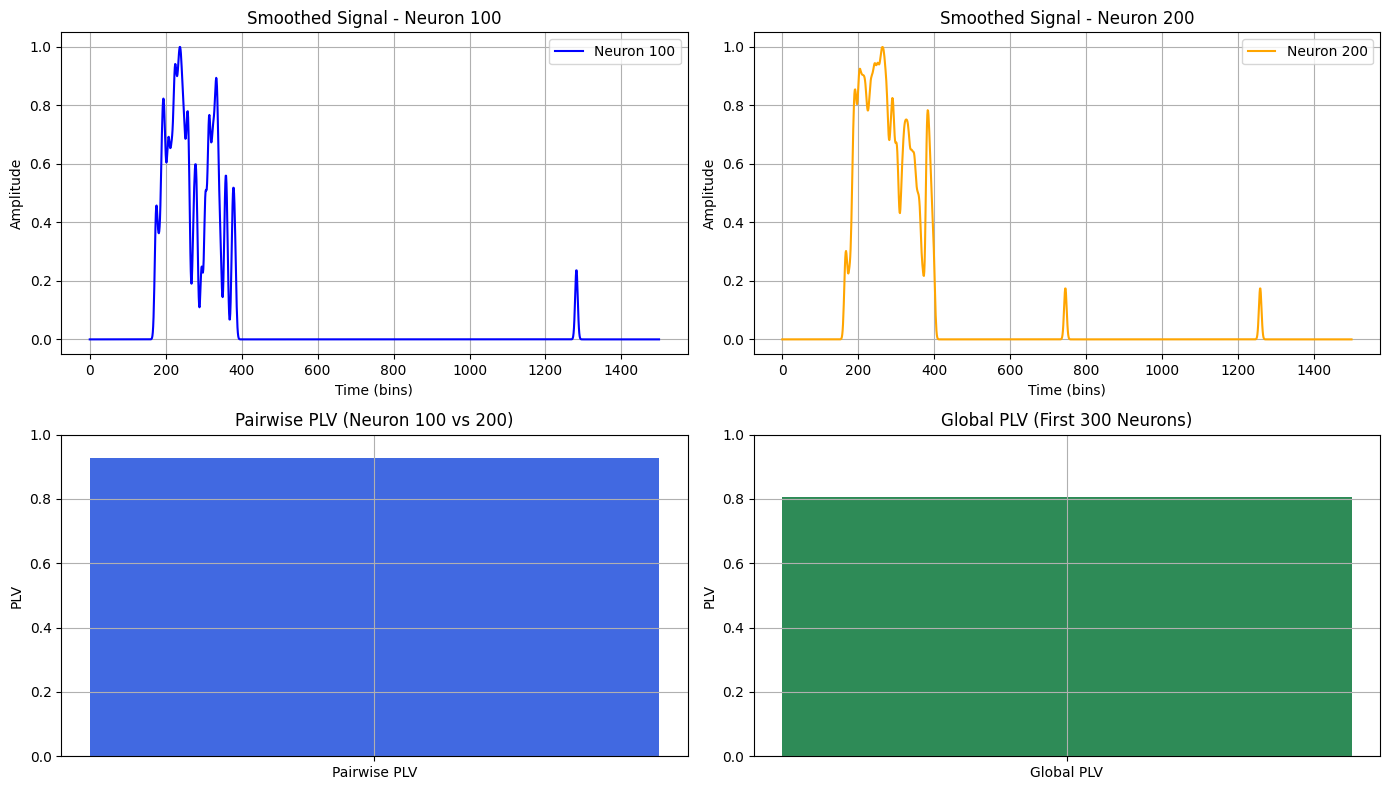

Pairwise PLV (Neuron 100 vs 200): 0.928
Global PLV (First 300 Neurons): 0.807


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# --- Smoothing Function ---
def smooth_spikes(spike_monitor, neuron_indices, bin_size=10*ms, duration=15*second):
    bins = int(duration / bin_size)
    signals = np.zeros((len(neuron_indices), bins))
    for idx, neuron_id in enumerate(neuron_indices):
        spike_times = spike_monitor.spike_trains()[neuron_id]
        indices = (spike_times / bin_size).astype(int)
        signals[idx, indices] = 1
    kernel = np.exp(-np.linspace(-3, 3, 30)**2)
    kernel /= kernel.sum()
    return np.array([np.convolve(sig, kernel, mode='same') for sig in signals])

# --- PLV Calculation Functions ---
def compute_plv(signal1, signal2):
    phase1 = np.angle(hilbert(signal1))
    phase2 = np.angle(hilbert(signal2))
    return np.abs(np.mean(np.exp(1j * (phase1 - phase2))))

def compute_global_plv(signals):
    n = signals.shape[0]
    plvs = []
    for i in range(n):
        for j in range(i + 1, n):
            plvs.append(compute_plv(signals[i], signals[j]))
    return np.mean(plvs)

# --- Analysis Parameters ---
bin_size = 4 * ms
duration = 15 * second
start_time = 2 * second
end_time = 8 * second

# --- Data Processing ---
neuron_indices = range(300)
smoothed_signals = smooth_spikes(exc_mon, neuron_indices, bin_size=bin_size, duration=duration)

start_idx = int(start_time / bin_size)
end_idx = int(end_time / bin_size)
windowed_signals = smoothed_signals[:, start_idx:end_idx]

# --- Normalize Safely ---
max_vals = np.max(windowed_signals, axis=1, keepdims=True)
max_vals[max_vals == 0] = 1
normalized_signals = windowed_signals / max_vals

# --- Compute PLVs ---
pairwise_plv = compute_plv(normalized_signals[100], normalized_signals[200])
global_plv = compute_global_plv(normalized_signals)

# --- Create 2×2 Combined Plot ---
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- Plot 1: Neuron 100 Signal ---
axs[0, 0].plot(normalized_signals[100], label="Neuron 100", color='blue')
axs[0, 0].set_title("Smoothed Signal - Neuron 100")
axs[0, 0].set_xlabel("Time (bins)")
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].legend()
axs[0, 0].grid(True)

# --- Plot 2: Neuron 200 Signal ---
axs[0, 1].plot(normalized_signals[200], label="Neuron 200", color='orange')
axs[0, 1].set_title("Smoothed Signal - Neuron 200")
axs[0, 1].set_xlabel("Time (bins)")
axs[0, 1].set_ylabel("Amplitude")
axs[0, 1].legend()
axs[0, 1].grid(True)

# --- Plot 3: Pairwise PLV ---
axs[1, 0].bar(['Pairwise PLV'], [pairwise_plv], color='royalblue')
axs[1, 0].set_title("Pairwise PLV (Neuron 100 vs 200)")
axs[1, 0].set_ylabel("PLV")
axs[1, 0].set_ylim(0, 1)
axs[1, 0].grid(True)

# --- Plot 4: Global PLV ---
axs[1, 1].bar(['Global PLV'], [global_plv], color='seagreen')
axs[1, 1].set_title("Global PLV (First 300 Neurons)")
axs[1, 1].set_ylabel("PLV")
axs[1, 1].set_ylim(0, 1)
axs[1, 1].grid(True)

# --- Show ---
plt.tight_layout()
plt.show()

# --- Output Metrics ---
print(f"Pairwise PLV (Neuron 100 vs 200): {pairwise_plv:.3f}")
print(f"Global PLV (First 300 Neurons): {global_plv:.3f}")

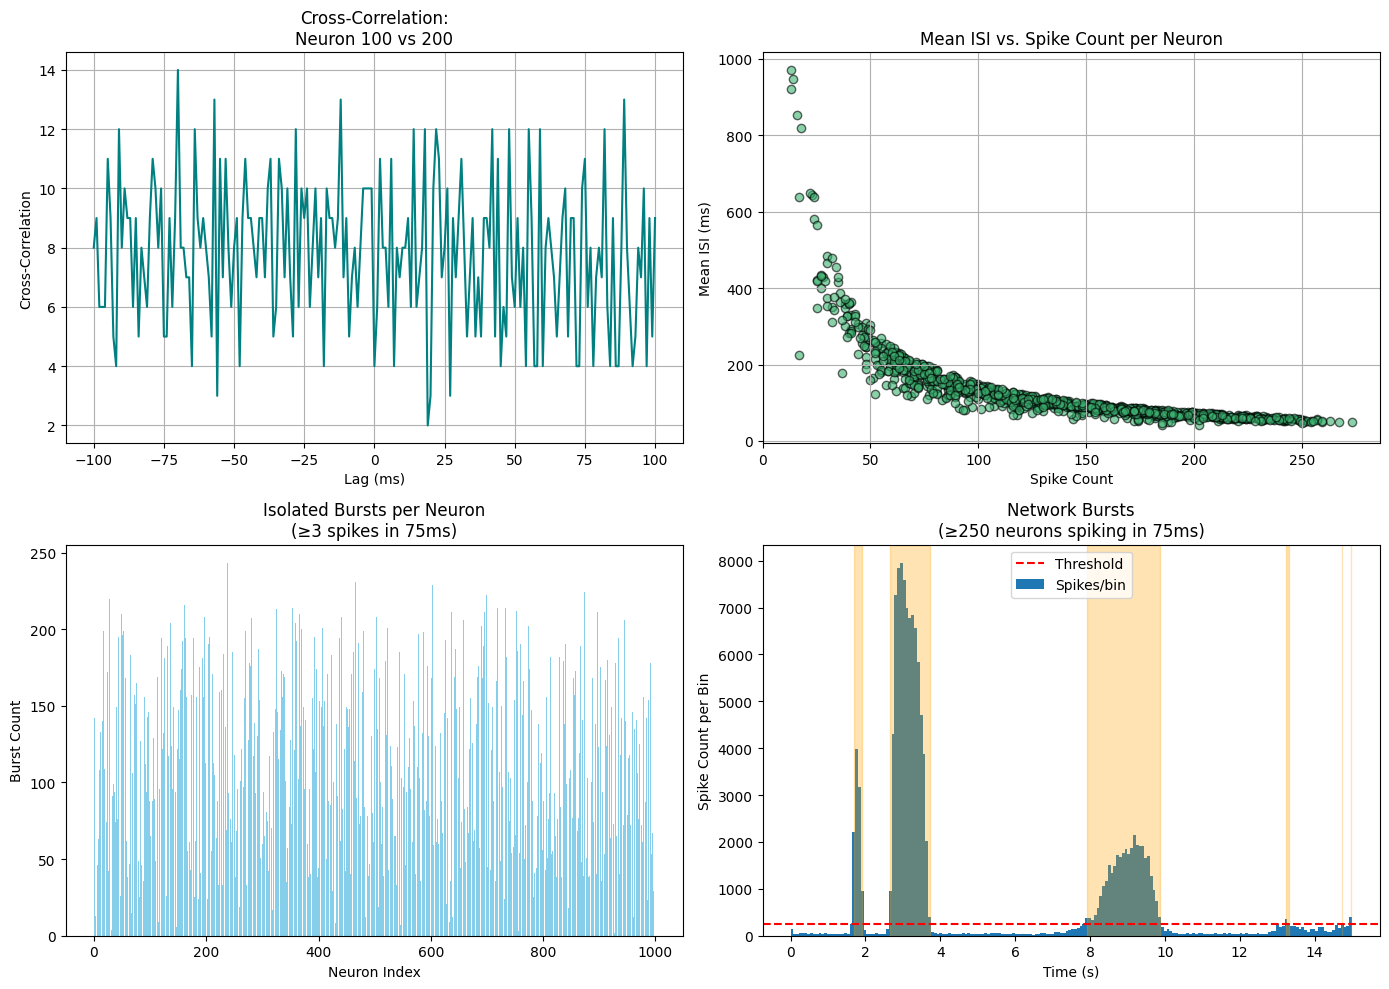

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# --- Cross-correlation Setup ---
neuron1_id = 100
neuron2_id = 200
bin_width = 1 * ms
lag_limit = 100  # in ms

spike_times_1 = exc_mon.spike_trains()[neuron1_id]
spike_times_2 = exc_mon.spike_trains()[neuron2_id]

time_bins = np.arange(0, duration/ms, bin_width/ms)
spike_train1, _ = np.histogram(spike_times_1/ms, bins=time_bins)
spike_train2, _ = np.histogram(spike_times_2/ms, bins=time_bins)

cross_corr = np.correlate(spike_train1, spike_train2, mode='full')
lags = np.arange(-len(spike_train1) + 1, len(spike_train1)) * bin_width/ms
lag_mask = (lags >= -lag_limit) & (lags <= lag_limit)
lags_limited = lags[lag_mask]
cross_corr_limited = cross_corr[lag_mask]

# --- Burst + ISI Setup ---
spike_times = np.array(exc_mon.t / ms)
spike_indices = np.array(exc_mon.i)
duration_ms = float(duration / ms)
n_exc = N_e

burst_window_ms = 75
min_spikes_for_burst = 3
min_fraction_for_network_burst = 0.25
bin_size_ms = 75

unique_neurons = np.unique(spike_indices)
mean_isis = []
spike_counts = []
burst_counts = {}

for neuron in unique_neurons:
    times = spike_times[spike_indices == neuron]
    count = len(times)
    if count > 1:
        isis = np.diff(times)
        mean_isis.append(np.mean(isis))
        spike_counts.append(count)
    else:
        mean_isis.append(np.nan)
        spike_counts.append(count)

    burst_count = 0
    if count >= min_spikes_for_burst:
        for i in range(count - min_spikes_for_burst + 1):
            window = times[i:i + min_spikes_for_burst]
            if window[-1] - window[0] <= burst_window_ms:
                burst_count += 1
    burst_counts[neuron] = burst_count

# --- Network Burst Analysis ---
n_bins = int(duration_ms / bin_size_ms)
bin_edges = np.linspace(0, duration_ms, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
histogram, _ = np.histogram(spike_times, bins=bin_edges)
active_neurons = len(np.unique(spike_indices))
network_threshold = int(np.ceil(min_fraction_for_network_burst * active_neurons))
burst_mask = histogram >= network_threshold
network_burst_labels, num_bursts = label(burst_mask)

# --- Create Combined Figure ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- Plot 1: Cross-Correlation ---
axs[0, 0].plot(lags_limited, cross_corr_limited, color='teal')
axs[0, 0].set_xlabel('Lag (ms)')
axs[0, 0].set_ylabel('Cross-Correlation')
axs[0, 0].set_title(f'Cross-Correlation:\nNeuron {neuron1_id} vs {neuron2_id}')
axs[0, 0].grid(True)

# --- Plot 2: Mean ISI vs Spike Count ---
axs[0, 1].scatter(spike_counts, mean_isis, alpha=0.6, color='mediumseagreen', edgecolor='black')
axs[0, 1].set_xlabel("Spike Count")
axs[0, 1].set_ylabel("Mean ISI (ms)")
axs[0, 1].set_title("Mean ISI vs. Spike Count per Neuron")
axs[0, 1].grid(True)

# --- Plot 3: Burst Count per Neuron ---
sorted_neurons = sorted(burst_counts.keys())
burst_values = [burst_counts[n] for n in sorted_neurons]
axs[1, 0].bar(sorted_neurons, burst_values, color='skyblue')
axs[1, 0].set_xlabel('Neuron Index')
axs[1, 0].set_ylabel('Burst Count')
axs[1, 0].set_title(f'Isolated Bursts per Neuron\n(≥{min_spikes_for_burst} spikes in {burst_window_ms}ms)')

# --- Plot 4: Network Burst Timeline ---
axs[1, 1].bar(bin_centers / 1000, histogram, width=(bin_edges[1] - bin_edges[0]) / 1000, label='Spikes/bin')
axs[1, 1].axhline(network_threshold, color='red', linestyle='--', label='Threshold')
for i in range(1, num_bursts + 1):
    burst_bins = bin_centers[network_burst_labels == i]
    if len(burst_bins) > 0:
        axs[1, 1].axvspan(burst_bins[0]/1000, burst_bins[-1]/1000, color='orange', alpha=0.3)
axs[1, 1].set_xlabel('Time (s)')
axs[1, 1].set_ylabel('Spike Count per Bin')
axs[1, 1].set_title(f'Network Bursts\n(≥{network_threshold} neurons spiking in {bin_size_ms}ms)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()